Insights
- Net of the Bellman equation, Q Values should be uniformly distributed across the state space.  This should make the agent more reliably choose the correct action, regardless of the location within the state space.  The next question is how to know whether the state space is uniformly sampled.  One way to check is to see whether Q values monotonically increase from 0 to 1, or 0.5 to 1.
- It's important to get the size of your replay buffer sized correctly, so that as epsilon declines, the NN learns from recently explored states.  As epsilon declines, the NN will be reinforcing better moves, so we need to sample from those moves.  If the replay buffer is too large, the NN will never see the good moves.
- Question: can we have multi-dimensional rewards?  For example - use a single agent.  If the agent is playing for player 1, it maximizes the reward, if player 2, it minimizes, and in both cases, it tries to avoid a draw.  The hard part here is if the draw is a negative reward, it appears as a desireable otucome for Player 2, which I think is bad.
- Why can't a DQN learn to block moves of an opponent?  If I were player 1, the blocking move should have the max reward, because all other moves would lead to a loss.  Why doesn't this occur?  This turned into a key challenge - the "optimistic agent" problem. We need to have an agent that will stymie the other agent in order to avoid losing.
- A human knows whose turn it is.  Therefore, whose turn it is shoudl be part of the state.  Where the agent goes will be different, depending on whose turn it is.

In [3]:
# Import Libraries
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
import matplotlib.pyplot as plt

torch.set_printoptions(precision=5, sci_mode=False)  # 5 decimal places, disable scientific notation

In [4]:
PLAYER_1 = 1
PLAYER_2 = -1

In [5]:
# Tic Tac Toe Environment - Use across tabular learning and DQN
# State defined as vect size 10

class TicTacToeEnv:
    def __init__(self):
        self.reset()

    def reset(self):
        self.board = np.zeros(9, dtype=int)  # 1D board of size 9
        self.current_player = 1  # 1 for X, -1 for O
        return self._get_state()

    def step(self, action):
        if self.board[action] != 0:
            raise ValueError("Invalid action: Position already occupied.")
        self.board[action] = self.current_player
        reward, done = self._check_game_status()
        self.current_player *= -1  # Switch player
        return self._get_state(), reward, done

    def valid_actions(self):
        #return [i for i in range(9) if self.board[i] == 0]
        return np.array([i for i in range(9) if self.board[i] == 0])

    # Note that state is a vector of length 10
    def _get_state(self):
        return np.append(self.board, self.current_player)

    # Return [who won], [is_done]
    def _check_game_status(self):
        for combo in [(0, 1, 2), (3, 4, 5), (6, 7, 8), (0, 3, 6), (1, 4, 7), (2, 5, 8), (0, 4, 8), (2, 4, 6)]:
            if abs(self.board[combo[0]] + self.board[combo[1]] + self.board[combo[2]]) == 3:
                return (1 if self.current_player == 1 else -1), True
        if 0 not in self.board:
            return 0, True  # Draw
        return 0, False  # Continue game
    
    def get_final_reward( self, state ):
        player = state[9]
        for combo in [(0, 1, 2), (3, 4, 5), (6, 7, 8), (0, 3, 6), (1, 4, 7), (2, 5, 8), (0, 4, 8), (2, 4, 6)]:
            if abs( state[combo[0]] + state[combo[1]] + state[combo[2]]) == 3:
                return (1 if player == 1 else -1), True
        if 0 not in state:
            return 0, True  # Draw
        return 0, False  # Continue game
    
    # Print Board
    def render(self):
        symbols = {0: ".", 1: "X", -1: "O"}
        for i in range(0, 9, 3):
            print(" ".join(symbols[self.board[j]] for j in range(i, i + 3)))
        #print()

    def state_to_indx( self ):
        output = 0
        output = self.current_player + 1
        scale_val = 3
        for idx in range(9):
            output = output + scale_val * (self.board[idx] + 1)
            #print( output )
            scale_val = scale_val * 3
        return output

In [6]:
# Try a hashkey for the dictionary instead of the tuple approach - tried unique int key
# Try copying the reward into the Q-value when is_done = True

class TabularAgent:
    def __init__(self
                 , learning_rate=0.1
                 , gamma=1 #0.99 # No need to discount because rewards are only terminal
                 , epsilon=1.0  # Always explore to start
                 , epsilon_decay=0.995
                 , epsilon_min=0.1
                 , debug_act=False
                 , learning_rate_decay=.999
                 , learning_rate_min=.01
                 , debug_update_q_value=False
                 , debug_get_q_value=False
                ):
        
        # initialize internal structures
        self.q_dict = {}  # Dictionary to store Q-values for state-action pairs
            # Note = each entry will include an estimate of the reward for state,action, and number of visits
        self.learning_rate = learning_rate
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.debug_act = debug_act
        self.learning_rate_decay = learning_rate_decay
        self.learning_rate_min = learning_rate_min
        self.debug_update_q_value = debug_update_q_value
        self.debug_get_q_value = debug_get_q_value
        self.non_zero_q_values=0

    # Map board, action to unique key for Q table dictionary.  Based on mod3 logic because
    # every place on the board can have 3 states
    # bug?  Are we missing the player?
    def gen_key(self, state, action ):
        output = action #[0-8].  LSD.  This takes up 3^2 units of the key state space.
        scale_val = 9
        for idx in range(10):
            #print(output)
            output = output + scale_val * (state[idx] + 1)
            scale_val = scale_val * 3
        return output
    
    # Get the Q-value for a given state-action pair. If it doesn't exist, initialize it to 0.
    def get_q_value(self, state, action):
        #if( self.debug_get_q_value ):
            #print( "[get_q_val]. Board = ", state[:9], "player = ", state[9], "action = ", action)

        # Generate key from state, action
        key = self.gen_key( state, action)
        if( self.debug_get_q_value ):
            print( "Get Q Val: key: ", key )

        # If entry doesn't exist, add a new entry, and initialize q-value to zero, visits to 0
        q_value = 0.0
        num_visits = 0
        if key not in self.q_dict:
            if( self.debug_get_q_value ):
                print( "adding to Q-table!")
            self.q_dict[ key ] = [q_value, num_visits]  # 0.0 reward, 0 visits
        else:
            [q_value, num_visits] = self.q_dict[ key ]
            #self.q_dict[key][1] = num_visits+1
            
        if( self.debug_get_q_value ):
            print( "Get Q Val: q_value: ", q_value )
            print()
        return q_value, num_visits

    # Set a Q-value for a board-action pair
    def set_q_value(self, key, value):
        # key = self.gen_key( board, action)
        if(key in self.q_dict):
            self.q_dict[ key ][0] = value
        else:
            self.q_dict[ key ] = [ value, 1 ]
        return
            

    # Update the Q-value for the given state-action pair using the Bellman equation.
    # Look at this carefully!
    def update_q_value(self, state, action, reward, next_state, done, env):
        # If terminal state, Q-value is updated using the immediate reward.  No bellman equation needed.
        if done:
            target = reward
            if( self.debug_update_q_value ):
                print( "    Update Q Value: done!  Setting target to reward: ", target )
                valid_actions = "not applicable"
                q_values = "not applicable"
                curr_q_value = "not applicable"
            
        # if non-terminal, then evaluate the q-values of the next actions
        else:
            # Get valid moves from next_state... then calc Q-values of next moves, then take the max/min
            # valid_actions = np.array([i for i in range(9) if state[i] == 0])
            valid_actions = np.array([i for i in range(9) if next_state[i] == 0])
            if( self.debug_update_q_value ):
                print( "    Update Q Value: Valid actions: ", valid_actions )
            
            # If there is only a single valid move left, we can directly calculate the terminal target
            # Q value.  Set the terminal Q value
            if( len( valid_actions ) == 1 ):
                # Initialize final state - make copy to avoid altering the next_state in the training loop
                final_state = np.array(next_state, dtype=int)                               
                # Make the final move
                final_state[valid_actions[0]] = next_state[9]                       
                # Toggle the player
                final_state[9] *- -1
                # compute the final reward, which is also the target
                target, done = env.get_final_reward( final_state )
                # Debug
                if( not done ):
                    print( "ERROR: Should be in final state!" )

                # Set terminal Q value
                terminal_key = self.gen_key( next_state, valid_actions[0])
                if( terminal_key not in self.q_dict ):
                    self.q_dict[ terminal_key ] = [target, 1]
                else:
                    self.q_dict[ terminal_key ][0] = target
                    self.q_dict[ terminal_key ][1] += 1

                if( self.debug_update_q_value ):
                    print( "    Update Q Value: penultimate move!  Setting target: ", target )
                    valid_actions = "not applicable"
                    q_values = "not applicable"
                    curr_q_value = "not applicable"

            # We're more than 1 move from the end
            else:
                # Extract the Q-value of the next state to compute the target
                #q_values = [self.get_q_value(state, action)[0] for action in valid_actions]
                q_values = [self.get_q_value(next_state, action)[0] for action in valid_actions] # Some of these exceed 1!!
    
                # Set target Q value based on discount factor
                if( next_state[9] == PLAYER_1 ):
                    # If current player is 1, the Q-value of the NEXT [state, action] will be chosen from player 2's perspective
                    # I think this is a bug -- this can exceed 1 - which doesn't make sense, as the max reward is 1
                    target = reward + self.gamma * max(q_values) # This could technically go lower than -1
                else:
                    # If player 2 is current player, then player 1 is the next player, and will seek the max reward
                    target = reward + self.gamma * min(q_values) # This could technically go larger than 
            
            if( abs( target ) > 1 ):
                target = np.clip(target, -1, 1)
                print( "ERROR: HAD TO CLIP TARGET!" )

        # Update the Q-value using the learning rate
        key = self.gen_key( state, action)
        curr_q_val, num_visits = self.get_q_value(state, action)
        self.q_dict[key][0] = curr_q_val + self.learning_rate * (target - curr_q_val) #CHECK THIS VIA SUTTON & BARTON
        if( self.debug_update_q_value ):
            print( "UPDATED q_value key: ", key )
            print( "UPDATED q_value: ", self.q_dict[key][0] )

        # Increment num_visits for the state-action
        self.q_dict[key][1] += 1

        if( self.debug_update_q_value ):
            if( 1 ): #target != 0 and target != 1 and target != -1 and curr_q_val == 0):
                print( "non-trivial q_value update. Player: ", state[9], "made move ", action , "from state:" )
                self.render( state )
                print( "  resulting in state: " )
                self.render( next_state)
                print( "reward: ", reward, "done: ", done )
                print( "Valid actions from next state: ", valid_actions )
                print( "Valid Q values from next state:", q_values )
                print( "current_q_val, of CURRENT state, action: ", curr_q_val )
                print( "target -- IMPORTANT -- (reward if done, reward if next state done, or max/min(Q-next): ", target )
                print( "updated_q_val calculated: ", curr_q_val + self.learning_rate * (target - curr_q_val) )
                # There is a bug - this should never be more than 1
                print( "confirmed_q_val        : ", self.get_q_value(state, action)[0] ) # This should never be more than 1
                print()
        
        # Update Learning Rate - reduce over time
        self.update_learning_rate()
        return
        
    
    # Choose an action using epsilon-greedy
    def choose_action(self, state):
        if( self.debug_act ):
            print( "    Debug Act: input state: (last num is player)" )
            print( "    ", state )
            print( "    Epsilon: ", self.epsilon )

        # Derive valid actions
        valid_actions = np.array([i for i in range(9) if state[i] == 0])
        if( self.debug_act ):
            print( "    valid_actions: ", valid_actions )

        # Choose moves via epsilon-greedy
        if random.random() < self.epsilon:
            if( self.debug_act ):
                print( "    Random move!" )
                #print( "    Valid actions: ", valid_actions )
                
            # Randomly choose an index if the value of state[index] is 0
            # Get the number of visits for each valid action
            num_visits = np.array([self.get_q_value(state, action)[1] for action in valid_actions])

            # Find the minimum number of visits
            min_visits = np.min(num_visits)
            
            # Get actions that have the minimum number of visits
            least_explored_actions = valid_actions[num_visits == min_visits]
            
            # Randomly select from the least explored actions
            move = np.random.choice(least_explored_actions)

            # Previous naive logic
            #move = np.random.choice(valid_actions)
        else:
            if( self.debug_act ):
                print( "Using Tabular Q agent to move!" )

            # Get Q values from valid actions
            valid_move_q_values = [self.get_q_value(state, action) for action in valid_actions]
            if( state[9] == PLAYER_1 ):
                best_q_value = max(valid_move_q_values)
            else:
                best_q_value = min(valid_move_q_values)

            # If all Q-values are tied, choose randomly among the best actions
            best_actions = [action for action, q in zip(valid_actions, valid_move_q_values) if q == best_q_value]
            move = np.random.choice(best_actions)

            if( self.debug_act ):
                print( "Valid actions: ", valid_actions )
                print( "Q values of valid actions: ", valid_move_q_values )
                print( "Best Actions: ", best_actions )
        
        if( self.debug_act ):        
            print( "    Selected Move: ", move )
            print()

        # Return chosen move
        return move

    
    def update_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def update_learning_rate(self):
        self.learning_rate = max(self.learning_rate_min, self.learning_rate * self.learning_rate_decay)

    # Save the Q-table to a file
    def save_q_table(self, filename):
        np.save(filename, self.q_dict)

    # Load Q-table from a file
    def load_q_table(self, filename):
        self.q_dict = np.load(filename, allow_pickle=True).item()
        print( "Loaded Q-table.  Size: ", len(self.q_dict) )

    # Print Board
    def render(self, board):
        symbols = {0: ".", 1: "X", -1: "O"}
        for i in range(0, 9, 3):
            print(" ".join(symbols[board[j]] for j in range(i, i + 3)))
        #print()

In [7]:
# Training loop for Tabular Q learning
def train_tic_tac_toe_tabular(agent, episodes=1000, plot_interval=500, debug=False):
    env = TicTacToeEnv()

    # Iterate through each episode
    for episode in range(1, episodes + 1):
        if( debug ):
            print()
            print( "Training loop.  Starting Episode: ", episode )
        
        # Reset the state -- note that the state is now a 10-element vector
        state = env.reset()
        done = False
        
        # Play until the episode is done
        while not done:
            if( debug ):
                print( " Current State: " )
                env.render()
                print( "state sync verify: ", state )
            
            # Decide on a move, given the agent and the state
            action = agent.choose_action(state) # applies epsilon greedy logic to choose the action

            # Make the move
            next_state, reward, done = env.step(action)
            if( debug ):
                print( "Move chosen: ", action)
                print( "Reward: ", reward, " Done: ", done )
                print( "Next state: ", next_state )
                #env.render()

            # Learn from the move - This is the key place where learning happens
            agent.update_q_value(state, action, reward, next_state, done, env)

            # Update the state
            state = next_state
        
        # Update epsilon if we're using epsilon-greedy move choice
        agent.update_epsilon()

        if episode % plot_interval == 0:
            print(f"Episode {episode}, Q-Table Size: {len( agent.q_dict) }, Epsilon: {agent.epsilon}, LR: {agent.learning_rate}" )

    # Save the trained Q-table!
    agent.save_q_table('tic_tac_toe_tabular_q_dict')

In [8]:
# Test creating a tabular Q agent
tabular_q_agent = TabularAgent(
    learning_rate=0.125
    , gamma=0.99
    , epsilon=1.0
    , epsilon_decay=0.9999
    , epsilon_min=0.75
    , debug_act=False
    , learning_rate_decay=1 # Don't decay!  Always learn!
    , learning_rate_min=.1
    , debug_get_q_value=False
    , debug_update_q_value=False
    )

In [9]:
# Test training the tabular Q agent
train_tic_tac_toe_tabular(tabular_q_agent, episodes=50000, plot_interval=100, debug=False)

# There are 5,478 states unique states.  However, there are more Q-values, because there can be multiple actions per legal state

Episode 100, Q-Table Size: 2365, Epsilon: 0.9900493386913721, LR: 0.125
Episode 200, Q-Table Size: 3924, Epsilon: 0.980197693043223, LR: 0.125
Episode 300, Q-Table Size: 5247, Epsilon: 0.970444077784251, LR: 0.125
Episode 400, Q-Table Size: 6448, Epsilon: 0.9607875174472562, LR: 0.125
Episode 500, Q-Table Size: 7394, Epsilon: 0.9512270462715811, LR: 0.125
Episode 600, Q-Table Size: 8305, Epsilon: 0.9417617081065252, LR: 0.125
Episode 700, Q-Table Size: 9134, Epsilon: 0.9323905563157222, LR: 0.125
Episode 800, Q-Table Size: 9841, Epsilon: 0.9231126536824614, LR: 0.125
Episode 900, Q-Table Size: 10543, Epsilon: 0.9139270723159584, LR: 0.125
Episode 1000, Q-Table Size: 11146, Epsilon: 0.9048328935585562, LR: 0.125
Episode 1100, Q-Table Size: 11748, Epsilon: 0.8958292078938495, LR: 0.125
Episode 1200, Q-Table Size: 12259, Epsilon: 0.886915114855721, LR: 0.125
Episode 1300, Q-Table Size: 12693, Epsilon: 0.8780897229382887, LR: 0.125
Episode 1400, Q-Table Size: 13007, Epsilon: 0.869352149506

In [38]:
# DQN Agent
# State = [board [9] + player [1] ]
# action_size specifies the number of action options we have

class DQNAgent:
    def __init__(self, state_size=10, action_size=9, hidden_size=128, gamma=0.99, lr=0.001, replay_buff_len=10000
                 , batch_size=64, tao=1.0, epsilon_start=.99, epsilon_decay=.999
                 , epsilon_min=0.05, use_epsilon_greedy = True, polyak_update_rate=0.001
                 , debug_replay_buffer=False, debug_NN_update=False, NN_update_print_freq=10
                 , debug_act=False):
        # Agent Parameters
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = gamma
        self.batch_size = batch_size
        self.tau = tao  # Boltzmann temperature
        self.epsilon = epsilon_start
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.use_epsilon_greedy = use_epsilon_greedy
        self.polyak_update_rate = polyak_update_rate
        self.debug_replay_buffer=debug_replay_buffer
        self.debug_NN_update = debug_NN_update
        self.num_nn_updates = 0
        self.NN_update_print_freq = NN_update_print_freq
        self.debug_act=debug_act
        
        # Initialize policy network and target network
        self.policy_net = self._build_model(hidden_size)
        self.target_net = self._build_model(hidden_size)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()  # We don't need to calculate gradients for target network

        # Initialize the Replay Buffer!
        self.replay_buffer = deque(maxlen=replay_buff_len)

        # Initialize optimizer -- this updates policy network weights via the learning rate
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)

        # Initialize the loss function
        self.loss_fn = nn.MSELoss()

        # Initialize training logs - update every time we update the policy network
        self.losses = []
        self.epsilons = []
        self.q_differences = []
        self.q_abs_differences = []

    # Helper function - this defines NN architecture!
    def _build_model(self, hidden_size):
        return nn.Sequential(
            nn.Linear(self.state_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, self.action_size),
        )

    # Helper function: Calculate the reward of a board state
    def get_final_reward( self, state ):
        player = state[9]
        for combo in [(0, 1, 2), (3, 4, 5), (6, 7, 8), (0, 3, 6), (1, 4, 7), (2, 5, 8), (0, 4, 8), (2, 4, 6)]:
            if abs( state[combo[0]] + state[combo[1]] + state[combo[2]]) == 3:
                return (1 if player == 1 else -1), True
        if 0 not in state:
            return 0, True  # Draw
        return 0, False  # Continue game

    # Helper function: return the target Q values from a batch sample from the replay buffer
    def calculate_target_q_values(self, states, actions, rewards, next_states, dones, batch_size):
        """
        Calculates target Q-values for training the DQN using replay buffer samples.
        
        Arguments:
        - states: Tensor of shape [batch_size, 10], current board state + player.
        - actions: Tensor of shape [batch_size], the actions taken.
        - rewards: Tensor of shape [batch_size], the rewards received.
        - next_states: Tensor of shape [batch_size, 10], next board state + player.
        - dones: Tensor of shape [batch_size], boolean values indicating terminal states.
        - batch_size: number of samples in the batch
        
        Returns:
        - target_q_values: Tensor of shape [batch_size, 1] for training. Used in updating target network.
        """
        target_q_values = torch.zeros(batch_size, 1)  # Placeholder for targets
    
        for i in range(batch_size):
            if dones[i]:  # Requirement 1: Use environment reward for terminal states
                target_q_values[i] = rewards[i]
                continue
            
            board = next_states[i, :9]  # Extract the board part
            player = next_states[i, 9]  # Extract the current player
    
            valid_actions = np.where(board == 0)[0]  # Legal moves
            
            if len(valid_actions) == 1:  # Requirement 2: If only 1 valid move
                final_state = next_states[i, :].clone()  # Create a copy to modify
                final_state[valid_actions[0]] = player  # Apply move
                [rwd, done] = self.get_final_reward(final_state)  # Get terminal reward
                if( not done ):
                    print( "BUG!  In second to last move, calculating the Q value of the next move should always be a terminal state!" )
                target_q_values[i] = rwd
            else:  # Requirement 3 & 4: Use target network for multiple valid moves
                with torch.no_grad():
                    next_q_values = self.target_net(next_states[i, :].clone().detach().float())
                    # next_q_values = self.target_net(torch.tensor(next_states[i, :], dtype=torch.float32))
                #next_q_values = self.target_net(torch.tensor(next_states[i,:], dtype=torch.float32)).detach()
                
                # Set illegal moves' Q-values to zero
                mask = (board != 0)  # Mask for illegal moves
                next_q_values[mask] = 0  # Set Q values for illegal moves to zero!
    
                # Requirement 4: Select min/max Q-value based on next player -> Bellman equation
                if player == PLAYER_1:
                    target_q_values[i] = rewards[i] + self.gamma * torch.max(next_q_values)
                else:
                    target_q_values[i] = rewards[i] + self.gamma * torch.min(next_q_values)
    
        return target_q_values
    
    # Choose an action based on the state - board + player
    def act(self, state):
        if( self.debug_act ):
            print( "input state: (last num is player)" )
            print( state )
        
        # Choose moves via epsilon-greedy
        if( self.use_epsilon_greedy ):
            # Evaluate whether we explore or exploit
            if random.random() < self.epsilon:
                if( self.debug_act ):
                    print( "Chose random move!" )
                
                # Randomly choose an index if the value of state[index] is 0
                return random.choice( [i for i in range(9) if state[i] == 0]) # Ignore last item
            else:
                if( self.debug_act ):
                    print( "Using policy agent to move!" )
                
                # Load whose perspective we're looking at
                player = state[9]
                
                # Choose the argmax if player 1, argmin if player 2
                with torch.no_grad(): # I think we use no_grad because we are only doing inference - no back prop
                    # Convert input state to a tensor
                    state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)

                    # Calculate Q-values via the policy network
                    #q_values = self.policy_net(state).detach().numpy()[0]
                    q_values = self.policy_net( state )  # Shape: (1, 9)
                    
                    # Derive legal actions
                    valid_actions = np.array([i for i in range(9) if state[0, i] == 0])

                    # Choose the action with the best Q-value among valid moves (largest if player 1, smallest if player 2)
                    #valid_q_values = q_values[valid_actions]  # Select Q-values for valid moves
                    valid_q_values = q_values[0, valid_actions]  # Select Q-values for valid moves

                    # Select the move.  If player 1, look for max Q-value.  If player 2, look for min.
                    if( player == 1 ):
                        move = valid_actions[torch.argmax(valid_q_values).item()]  # Map back to the actual move
                    else:
                        move = valid_actions[torch.argmin(valid_q_values).item()]  # Map back to the actual move
                    
                    # Print the state the agent sees, its q-values
                    if( self.debug_act ):
                        print( "Epsilon: ", self.epsilon )

                        print( "Q values: " )
                        q_grid = q_values.reshape(3, 3)
                        for row in q_grid:
                            print("  ".join([f"{val:.2f}" for val in row]))
                        print()

                        print( "Selected Move: ", move )

                    # Whole point of the function - return the move, based on the agent
                    return move
                    
        # Choose move via boltzmann - don't use for now
        else:
            # Convert input state to a tensor
            state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
            
            # Calculate Q-values via the policy network
            q_values = self.policy_net(state).detach().numpy()[0]
            
            # Derive legal actions
            valid_actions = np.array([i for i in range(9) if state[0, i] == 0])
    
            valid_q_values = q_values[valid_actions]
            exp_q = np.exp(valid_q_values / self.tau)
            probabilities = exp_q / np.sum(exp_q)
            return np.random.choice(valid_actions, p=probabilities)

    # Add result of the action to the replay buffer
    def remember(self, state, action, reward, next_state, done):
        self.replay_buffer.append((state, action, reward, next_state, done))

        if( self.debug_replay_buffer ):
            print( "Replay Buffer Log")
            print( "State: ", state )
            print( "Action: ", action )
            print( "Next State: ", next_state )
            print( "Reward: ", reward )
            print( "Done: ", done )
            print()

    # Update the neural network - THIS IS WHERE WE LEARN!
    # *******************************************************
    # 2/8/2025 - focus here
    def replay(self):
        # Decide whether we update the policy network
        if len(self.replay_buffer) < self.batch_size:
            return

        # Sample from the replay buffer. These are all calculated by playing the game
        # and rewards are calculated from the environment
        batch = random.sample(self.replay_buffer, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        # Convert samples from replay buffer into tensors
        states = torch.tensor(states, dtype=torch.float32)
        actions = torch.tensor(actions, dtype=torch.int64).unsqueeze(1)
        rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1)
        next_states = torch.tensor(next_states, dtype=torch.float32)
        dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1)

        # Calculate Q-Values of the actions taken from the starting states
        q_values = self.policy_net(states).gather(1, actions)
        
        # Calculate target_q_values - three cases: 1/ terminal, 2/ one more legal move, 3 >1 legal moves
        target_q_values = self.calculate_target_q_values( states
                                                         , actions
                                                         , rewards
                                                         , next_states
                                                         , dones
                                                         , self.batch_size)
        
        # Calculate the scalar loss between the Q values estimated from the policy
        # network and the Q-value targets calculated from the bellman equation and
        # the target network.
        loss = self.loss_fn(q_values, target_q_values)
        
        # Zero out gradients
        self.optimizer.zero_grad()
        
        # Calculate the gradient
        loss.backward()

        # Update the policy network
        self.optimizer.step()

        # Track training progress
        self.losses.append(loss.item())
        self.epsilons.append(self.epsilon)
        self.q_differences.append( torch.sum( q_values - target_q_values ).item())
        self.q_abs_differences.append( torch.sum( torch.abs( q_values - target_q_values) ).item())
        self.num_nn_updates += 1

        # Optional debug printout
        if( self.debug_NN_update and (self.num_nn_updates % self.NN_update_print_freq == 0) ):
            print( "Calculated q-values of state-action pairs: " )
            print( q_values.view(-1) )
            print( "Calculated targets of state-action pairs: " )
            print( target_q_values.squeeze() )
            print( "Diff: " )
            diff = q_values.squeeze() - target_q_values
            diff = diff.view(-1)  # Flatten the difference to a 1D tensor
            print( diff )
            print( "SumDiff: ", diff.sum().item() )
            print()
        
        return loss.item()

    def update_target_net(self):
        for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_( (1-self.polyak_update_rate) * target_param.data 
                                    + self.polyak_update_rate * policy_param.data )

    def update_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    # Print a board, and associated Q values of moves from the board
    def test(self, state):
        # Convert state to a tensor
        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        # Get Q-values from the policy network
        q_values = self.policy_net(state).detach().numpy()[0]
        board = state[0,:9].reshape(3, 3) # 
        for row in board:
            print(" ".join(["X" if x == 1 else "O" if x == -1 else "." for x in row]))
    
        # Print Q-values in a 3x3 grid
        print("\nQ-values (3x3 grid):")
        q_grid = q_values.reshape(3, 3)
        for row in q_grid:
            print("  ".join([f"{val:.2f}" for val in row]))
        print()
        return q_values

    def pretty_print_state(state):
        # Determine the player
        player = "Player 1" if state[9] == 1 else "Player -1"
        print(f"Turn: {player}")
    
        # Reshape the board and create a visual representation
        board = np.array(state[:9]).reshape(3, 3)
        board_visual = board.copy()
    
        # Replace values for better readability
        # 1 -> X (Player 1), -1 -> O (Player -1), 0 -> empty
        for i in range(3):
            for j in range(3):
                if board[i, j] == 1:
                    board_visual[i, j] = "X"
                elif board[i, j] == -1:
                    board_visual[i, j] = "O"
                else:
                    board_visual[i, j] = "."
    
        # Print the board
        print("\n".join([" | ".join(row) for row in board_visual]))
        print()  # Add an extra line for spacing


In [42]:
# Training Loop for DQN
def train_tic_tac_toe_DQN(agent, episodes=10000, train_move_freq = 1, update_target_game_freq = 1, plot_interval=500):
    env = TicTacToeEnv()
    
    # Iterate through each episode
    for episode in range(1, episodes + 1):
        # Reset the state -- note that the state is now a 10-element vector
        state = env.reset()
        done = False
        step = 0

        # Play until the episode is done
        while not done:
            # Decide on a move, given the agent and the state
            action = agent.act(state) # applies epsilon greedy logic to choose the action

            # Make the move
            next_state, reward, done = env.step(action)

            # Add to the replay buffer
            agent.remember(state, action, reward, next_state, done)

            # Update the state
            state = next_state

            # Train the network
            if( step % train_move_freq == 0 ):
                loss = agent.replay()
            step += 1

        # Update epsilon if we're using epsilon-greedy move choice
        agent.update_epsilon()

        # Update via the polyak soft updates to maintain network stability
        if( episode % update_target_game_freq == 0 ):
            agent.update_target_net()

        if episode % plot_interval == 0:
            print(f"Episode {episode}, Loss: {loss}")

    # Save the trained network!
    torch.save(agent.policy_net.state_dict(), 'tic_tac_toe_dqn.pth')

In [55]:
# Initialize the DQN Agent!
agent = DQNAgent(state_size=10                 # board + player
                 , action_size=9               # board size
                 , hidden_size=128             # hidden layer
                 , gamma=0.99                  # Bellman equation - discount factor for rewards
                 , lr=0.001                    # Learning rate in the optimizer function (Adam)
                 , replay_buff_len=1000        # Longer means we look back farther.  Shorter means we bias for more recent experience
                 , batch_size=64               # Number of replay examples we sample from for each back propagation update
                 , tao=1.0                     # This is for boltzman move choice logic
                 , epsilon_start=.99           # Starting epsilon value
                 , epsilon_decay=.9995         # Epsilon decay every time it's updated
                 , epsilon_min=0.2             # Minimum exploration factor
                 , use_epsilon_greedy = True   # Decides epsilon greedy vs. boltzman
                 , polyak_update_rate=0.001    # Soft update factor for updating target network
                 , debug_replay_buffer=False   # Print debug info for replay buffer additions
                 , debug_NN_update=False       # Prints Q-values, Target Q vals, and Diff -- sanity check learning
                 , NN_update_print_freq=1      # Print NN update info every 1 / NN_update_print_freq back propagations
                 , debug_act=False             # Print information about Q values and move chosen when acting
    )

In [56]:
# Train the DQN agent!
losses = train_tic_tac_toe_DQN(agent
                               , episodes=5000
                               , train_move_freq = 1
                               , update_target_game_freq = 1
                               , plot_interval=1)

Episode 1, Loss: None
Episode 2, Loss: None
Episode 3, Loss: None
Episode 4, Loss: None
Episode 5, Loss: None
Episode 6, Loss: None
Episode 7, Loss: None
Episode 8, Loss: None
Episode 9, Loss: 0.07296059280633926
Episode 10, Loss: 0.054249078035354614
Episode 11, Loss: 0.03818141296505928
Episode 12, Loss: 0.049805138260126114
Episode 13, Loss: 0.025602269917726517
Episode 14, Loss: 0.03518495708703995
Episode 15, Loss: 0.04107566177845001
Episode 16, Loss: 0.01038694754242897
Episode 17, Loss: 0.012402748689055443
Episode 18, Loss: 0.017145713791251183
Episode 19, Loss: 0.007016901858150959
Episode 20, Loss: 0.013383802957832813
Episode 21, Loss: 0.013123402372002602
Episode 22, Loss: 0.029546091333031654
Episode 23, Loss: 0.023701028898358345
Episode 24, Loss: 0.007545883767306805
Episode 25, Loss: 0.006833547726273537
Episode 26, Loss: 0.009916604496538639
Episode 27, Loss: 0.004714116454124451
Episode 28, Loss: 0.014558443799614906
Episode 29, Loss: 0.021479018032550812
Episode 30,

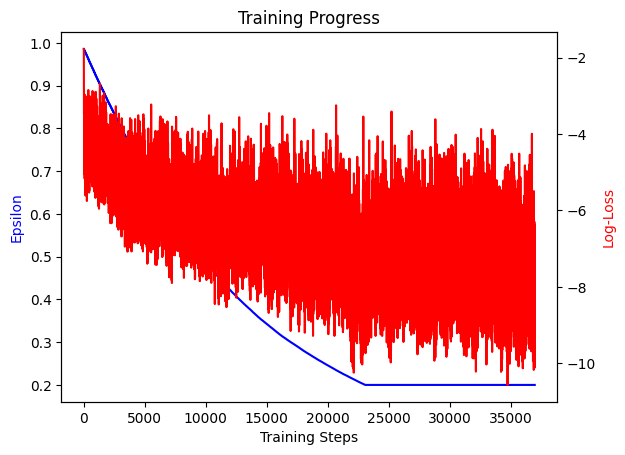

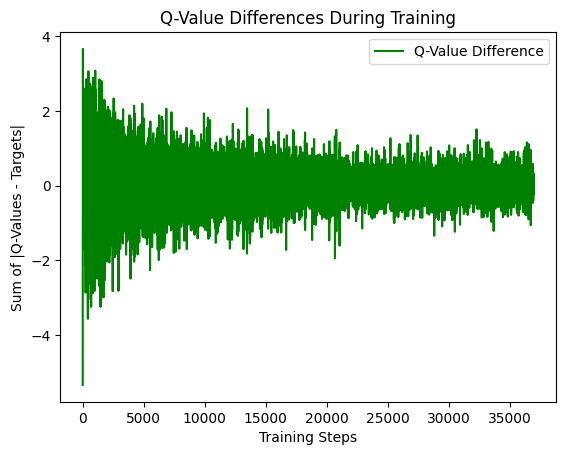

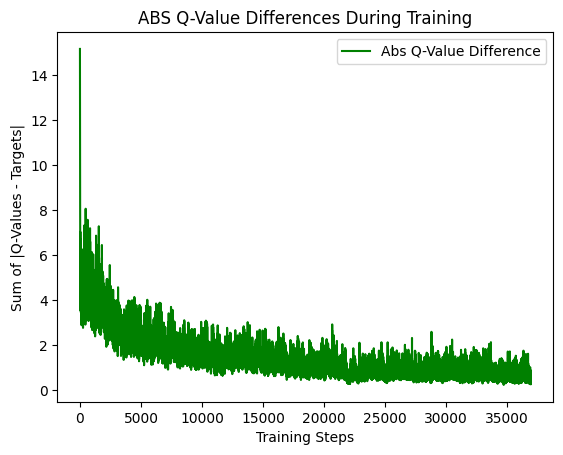

In [57]:
# Plot training progress!
fig, ax1 = plt.subplots()

# Epsilon on primary axis
ax1.plot(range(len(agent.epsilons)), agent.epsilons, 'b-', label='Epsilon')
ax1.set_xlabel('Training Steps')
ax1.set_ylabel('Epsilon', color='b')

# Loss on secondary axis
ax2 = ax1.twinx()
ax2.plot(range(len(agent.losses)), np.log(agent.losses), 'r-', label='LogLoss')
ax2.set_ylabel('Log-Loss', color='r')

plt.title('Training Progress')
plt.show()

plt.figure()
plt.plot(range(len(agent.q_differences)), agent.q_differences, 'g-', label='Q-Value Difference')
plt.xlabel('Training Steps')
plt.ylabel('Sum of |Q-Values - Targets|')
plt.title('Q-Value Differences During Training')
plt.legend()
plt.show()

plt.figure()
plt.plot(range(len(agent.q_abs_differences)), agent.q_abs_differences, 'g-', label='Abs Q-Value Difference')
plt.xlabel('Training Steps')
plt.ylabel('Sum of |Q-Values - Targets|')
plt.title('ABS Q-Value Differences During Training')
plt.legend()
plt.show()

In [63]:
# *********** PLAY PLAY PLAY **********
# Play against an agent you choose

#agent_choice = "tabular" #"DQN"

def play_against_agent( agent_choice ):
    # Create the game environment
    env = TicTacToeEnv()

    agent_choice = input("Do you want to play against Q-table agent (T), or DQN (D): ")
    while agent_choice not in ['T', 'D']:
        agent_choice = int(input("Invalid choice. Choose 'Q' or 'D' "))
    
    if( agent_choice == "D" ):
        print( "You chose to play against the DQN!" )
        # Create the agent neural network
        agent = DQNAgent(state_size=10                 # board + player
                     , action_size=9               # board size
                     , hidden_size=128             # hidden layer
                     , gamma=0.99                  # Bellman equation - discount factor for rewards
                     , lr=0.001                    # Learning rate in the optimizer function (Adam)
                     , replay_buff_len=128         # Longer means we look back farther.  Shorter means we bias for more recent experience
                     , batch_size=64               # Number of replay examples we sample from for each back propagation update
                     , tao=1.0                     # This is for boltzman move choice logic
                     , epsilon_start=0             # Starting epsilon value
                     , epsilon_decay=0             # Epsilon decay every time it's updated
                     , epsilon_min=0.00            # Minimum exploration factor
                     , use_epsilon_greedy = True   # Decides epsilon greedy vs. boltzman
                     , polyak_update_rate=0.001    # Soft update factor for updating target network
                     , debug_replay_buffer=False   # Print debug info for replay buffer additions
                     , debug_NN_update=False       # Prints Q-values, Target Q vals, and Diff -- sanity check learning
                     , NN_update_print_freq=1      # Print NN update info every 1 / NN_update_print_freq back propagations
                     , debug_act=True              # Print information about Q values and move chosen when acting
        )
    
        # Load the coefficients into the network
        agent.policy_net.load_state_dict(torch.load("tic_tac_toe_dqn.pth"))
    
        # Set agent to not track gradients -- only evaluate Q values based on state
        agent.policy_net.eval()
        
    elif( agent_choice == 'T' ):
        print( "You chose to play against the Q-Table!" )
        agent = TabularAgent(
            learning_rate=0.125
            , gamma=0.0
            , epsilon=0             # Never explore!
            , epsilon_decay=1       # no need to decay!
            , epsilon_min=0.0       # Keep exploiting all the time
            , debug_act=True
            , learning_rate_decay=1 # Don't decay!  Always learn!
            , learning_rate_min=.1
            , debug_get_q_value=False
            , debug_update_q_value=False
        )
        agent.load_q_table('tic_tac_toe_tabular_q_dict.npy')

    # Get whether the user wants to play X or O
    player = int(input("Do you want to be Player 1 (X) or Player 2 (O)? [1/-1]: "))
    while player not in [1, -1]:
        player = int(input("Invalid choice. Choose 1 for Player 1 (X) or -1 for Player 2 (O): "))

    # Start with a blank board
    state = env.reset()
    env.render()

    while True:
        # Solicit move from player
        if env.current_player == player:
            move = int(input("Enter your move [1-9]: "))
            move = move - 1
            if state[move] != 0:
                print("Invalid move. Try again.")
                continue

        # Use the agent to make a move
        else:
            if( agent_choice == 'D' ):
                with torch.no_grad():
                    move = agent.act(state)  # Make sure epsilon is 0 so that we always make move with the policy network
            elif( agent_choice == 'T' ):
                move = agent.choose_action( state )
        state, reward, done = env.step(move)
        env.render()
        print()

        if done:
            #if reward == 1 and env.current_player != player:
            if reward == player:
                print("Congratulations, you're still smarter than a neural network!")
            elif reward == -1 * player:
                print("You lost to the neural network!")
            else:
                print("It's a draw!")
            break

# Call the function to play!!
play_against_agent(agent_choice)

Do you want to play against Q-table agent (T), or DQN (D):  T


You chose to play against the Q-Table!
Loaded Q-table.  Size:  16167


Do you want to be Player 1 (X) or Player 2 (O)? [1/-1]:  1


. . .
. . .
. . .


Enter your move [1-9]:  1


...

X . .
. O .
. . X

    Debug Act: input state: (last num is player)
     [ 1  0  0  0 -1  0  0  0  1 -1]
    Epsilon:  0
    valid_actions:  [1 2 3 5 6 7]
Using Tabular Q agent to move!
Valid actions:  [1 2 3 5 6 7]
Q values of valid actions:  [(0.0, 42), (0.14149209908678168, 42), (0.0, 42), (0.0, 42), (0.13069541028742332, 42), (0.0, 41)]
Best Actions:  [7]
    Selected Move:  7

X . .
. O .
. O X



Enter your move [1-9]:  2


X X .
. O .
. O X

    Debug Act: input state: (last num is player)
     [ 1  1  0  0 -1  0  0 -1  1 -1]
    Epsilon:  0
    valid_actions:  [2 3 5 6]
Using Tabular Q agent to move!
Valid actions:  [2 3 5 6]
Q values of valid actions:  [(0.0, 14), (0.2975053171813488, 9), (0.3601487506600097, 9), (0.26626495555043217, 8)]
Best Actions:  [2]
    Selected Move:  2

X X O
. O .
. O X



Enter your move [1-9]:  4


X X O
X O .
. O X

    Debug Act: input state: (last num is player)
     [ 1  1 -1  1 -1  0  0 -1  1 -1]
    Epsilon:  0
    valid_actions:  [5 6]
Using Tabular Q agent to move!
Valid actions:  [5 6]
Q values of valid actions:  [(0.8819329129787512, 16), (-0.8819329129787512, 16)]
Best Actions:  [6]
    Selected Move:  6

X X O
X O .
O O X

You lost to the neural network!


In [83]:
# Test the agents randomly

agent = 'T'
num_games = 1000
rand_player = -1
if( agent == 'D' ):
    agent_path = "tic_tac_toe_dqn.pth"
else:
    agent_path = "tic_tac_toe_tabular_q_dict.npy"



def random_test( num_games=1000, rand_player=1, agent_type='D', agent_path="tic_tac_toe_dqn.pth"):
    print( "Agent is player ", rand_player * -1 )
    
    # initialize output
    num_win = num_loss = num_tie = 0

    # Create the game environment
    env = TicTacToeEnv()
    
    if( agent_type == 'D' ):
        agent = DQNAgent(state_size=10             # board + player
                     , action_size=9               # board size
                     , hidden_size=128             # hidden layer
                     , gamma=0.99                  # Bellman equation - discount factor for rewards
                     , lr=0.001                    # Learning rate in the optimizer function (Adam)
                     , replay_buff_len=128         # Longer means we look back farther.  Shorter means we bias for more recent experience
                     , batch_size=64               # Number of replay examples we sample from for each back propagation update
                     , tao=1.0                     # This is for boltzman move choice logic
                     , epsilon_start=0             # Starting epsilon value
                     , epsilon_decay=0             # Epsilon decay every time it's updated
                     , epsilon_min=0.00            # Minimum exploration factor
                     , use_epsilon_greedy = True   # Decides epsilon greedy vs. boltzman
                     , polyak_update_rate=0.001    # Soft update factor for updating target network
                     , debug_replay_buffer=False   # Print debug info for replay buffer additions
                     , debug_NN_update=False       # Prints Q-values, Target Q vals, and Diff -- sanity check learning
                     , NN_update_print_freq=1      # Print NN update info every 1 / NN_update_print_freq back propagations
                     , debug_act=False             # Print information about Q values and move chosen when acting
        )
    
        # Load the coefficients into the network
        agent.policy_net.load_state_dict( torch.load( agent_path ) )
    
        # Set agent to not track gradients -- only evaluate Q values based on state
        agent.policy_net.eval()

    elif( agent_type == 'T' ):
        agent = TabularAgent(
            learning_rate=0.125
            , gamma=0.0
            , epsilon=0             # Never explore!
            , epsilon_decay=1       # no need to decay!
            , epsilon_min=0.0       # Keep exploiting all the time
            , debug_act=False
            , learning_rate_decay=1 # Don't decay!  Always learn!
            , learning_rate_min=.1
            , debug_get_q_value=False
            , debug_update_q_value=False
        )
        agent.load_q_table( agent_path )

    # Loop through the games
    for episode in range( num_games ):
        #print( "game ", episode )
        done = False
        
        # reset board
        state = env.reset()
        #env.render()
        #print()
        
        while not done:
            current_player = env.current_player
            if( current_player == rand_player ):
                #print( "rand move" )
                # get valid actions
                valid_actions = env.valid_actions()
                # choose a random move
                move = np.random.choice( valid_actions )
            elif( agent_type == 'D' ):
                #print( "DQN" )
                with torch.no_grad():
                    move = agent.act(state)  # Make sure epsilon is 0 so that we always make move with the policy network
            elif( agent_type == 'T' ):
                #print( "Q-table" )
                move = agent.choose_action( state )
            else:
                print( "ERROR!  agent is undefined!  Must be 'D' or 'T'" )
                print( agent )
                
            state, reward, done = env.step(move)
            #env.render()
            #print()
            
            if( done ):
                if( reward == 0 ):
                    num_tie += 1
                elif( reward == rand_player ):
                    num_win += 1
                else:
                    num_loss += 1
                #print( "---------------------------------" )
        

    # Print Results
    print( "After ", episode+1, " games:" )
    print( "  random player wins: ", num_win )
    print( "  random player loss: ", num_loss)
    print( "  random player ties: ", num_tie)
    print( "  agent win rate: ", (num_loss / (num_win + num_tie + num_loss)) )
    
    return num_win, num_loss, num_tie

# Do random test!
random_test( num_games, rand_player, agent, agent_path)

Agent is player  1
Loaded Q-table.  Size:  16167
After  1000  games:
  random player wins:  0
  random player loss:  986
  random player ties:  14
  agent win rate:  0.986


(0, 986, 14)